# 03603351 Introduction to Data Science

---

## Medical insurance cost prediction
by machine learning (Linear regression)
*  แหล่งข้อมูล https://www.kaggle.com/datasets/mirichoi0218/insurance

<br>
เป้าหมาย (Objective) :

*   สร้างโมเดลทำนายค่าเบี้ยประกันสุขภาพที่แม่นยำ(ในสหรัฐอเมริกา)



<br>
ผลลัพธ์ที่ได้ (Key Result) :

*   ความแม่นยำ (R^2) : 86.5\%
*   ความคลาดเคลื่อนเฉลี่ย (MAE): $2,756.90 (ประมาณ 21\% จากค่าประกันเฉลี่ย ≈ \$13,000.00)

In [89]:
# install required libraries
# ใน colab ไม่จำเป็น

# !pip install gradio
# !pip install numpy
# !pip install pandas
# !pip install scikit-learn
# !pip install ipywidgets

In [90]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.inspection import PartialDependenceDisplay
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


##0.โหลดข้อมูล

In [91]:
df = pd.read_csv('../datasets/insurance.csv')

##1.ตรวจข้อมูลที่นำมาใช้

###1.1 ดูว่า Type ตรงไหม (ตรง)
เลขต้องเป็นพวกint/float ไม่ใช่ str/object

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


###1.2 ดูว่ามี null ไหม (ไม่มี)
จริงๆจะดูที่ Non-Null Count ของ .info() ก็ได้ <br>
ถ้า count < entries(rows) = มี null<br>
<br>
แต่จะดูยากกว่า!

In [93]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

###1.3ตรวจสอบข้อมูลซ้ำซ้อน (มี แต่ก็เป็นไปได้ เพราะ เราไม่ได้เก็บ ID)

ตัวอย่างโค้ดตรวจสอบ<br>

ตรวจ?

*   ซ้ำข้อมูลทุก columns `exact_dups = df.duplicated().sum()`
*   ซ้ำ ID `key_dups = df[df.duplicated(subset=['student_id'], keep=False)]`

In [94]:
exact_dups = df.duplicated().sum()
print(f"จำนวนแถวที่ซ้ำกันสมบูรณ์: {exact_dups} แถว")


จำนวนแถวที่ซ้ำกันสมบูรณ์: 1 แถว


###1.4 ตรวจสอบค่าผิดปกติ (Outliers Detection) (มีบ้างแต่ยังเป็นไปได้)

In [95]:
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [96]:
rows_count=len(df)
def check_all_outliers(df, cols=None):
    # ถ้าไม่ได้ระบุคอลัมน์ ให้เลือกคอลัมน์ที่เป็นตัวเลขทั้งหมดใน df
    if cols is None:
        cols = df.select_dtypes(include=['number']).columns

    for col in cols:
        outliers, low, high = find_outliers_iqr(df, col)
        count = len(outliers)
        percent = (count / rows_count) * 100

        print(f"ช่วงปกติของ {col}: [{low:.2f}, {high:.2f}]")
        print(f"พบ Outliers ใน {col} จำนวน {count} รายการ ({percent:.2f}%):")
        if count > 0:
            print(outliers[[col]])
        print("-" * 40)


In [97]:
check_all_outliers(df, ['age'])

ช่วงปกติของ age: [-9.00, 87.00]
พบ Outliers ใน age จำนวน 0 รายการ (0.00%):
----------------------------------------


In [98]:
check_all_outliers(df, ['children'])

ช่วงปกติของ children: [-3.00, 5.00]
พบ Outliers ใน children จำนวน 0 รายการ (0.00%):
----------------------------------------


In [99]:
check_all_outliers(df, ['bmi'])

ช่วงปกติของ bmi: [13.70, 47.29]
พบ Outliers ใน bmi จำนวน 9 รายการ (0.67%):
        bmi
116   49.06
286   48.07
401   47.52
543   47.41
847   50.38
860   47.60
1047  52.58
1088  47.74
1317  53.13
----------------------------------------


In [100]:
check_all_outliers(df, ['charges'])

ช่วงปกติของ charges: [-13109.15, 34489.35]
พบ Outliers ใน charges จำนวน 139 รายการ (10.39%):
          charges
14    39611.75770
19    36837.46700
23    37701.87680
29    38711.00000
30    35585.57600
...           ...
1300  62592.87309
1301  46718.16325
1303  37829.72420
1313  36397.57600
1323  43896.37630

[139 rows x 1 columns]
----------------------------------------


###1.5 ตรวจ business logic (ไม่มี)


*   age, bmi, children, charges ห้ามติดลบ

ตัวอย่างอื่นๆ เช่น คะแนนห้ามเกิน100



In [101]:
# แสดงแถวที่มีค่าติดลบในคอลัมน์ที่กำหนด
df[(df[['age', 'bmi', 'children', 'charges']] < 0).any(axis=1)]

,age,sex,bmi,children,smoker,region,charges


###1.6 ตรวจค่าเปลก

*   smoker ไม่ใช่ yes/no
*   sex ไม่ใช่ male/female
*   region ไม่ใช่ northEast/northWest/southEast/southWest



In [102]:
# ทาง1 ดึงแถวที่ค่าไม่อยู่ในรายการที่ถูกต้อง (Case-sensitive)
df[~df['smoker'].isin(['yes', 'no']) | ~df['sex'].isin(['male', 'female']) | ~df['region'].isin(['northeast', 'northwest', 'southeast', 'southwest'])]

,age,sex,bmi,children,smoker,region,charges


In [103]:
#ตัวอย่างกรณีกรองเจอ
df[~df['smoker'].isin(['no'])].head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
11,62,female,26.29,0,yes,southeast,27808.7251
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768


In [104]:
# ทาง2 พิมพ์ค่า Unique ของทั้ง 3 คอลัมน์ออกมาดู
#แล้วกวาดตามอง
for col in ['smoker', 'sex', 'region']: print(f"{col}: {df[col].unique().tolist()}")

smoker: ['yes', 'no']
sex: ['female', 'male']
region: ['southwest', 'southeast', 'northwest', 'northeast']


##2.ทำความสะอาดข้อมูล หรือ เปลี่ยนชุดข้อมูล/หาข้อมูลใหม่(ถ้าเกินเยียวยา)

ข้อมูลที่นำมาใช้ครั้งนี้ไม่มีอะไรต้องแก้

##3.CDA,Confirmatory Data Analysis, "การวิเคราะห์ข้อมูลเชิงยืนยัน"
คือการตรวจสอบสมมติฐานหรือทฤษฎีที่เรามีอยู่แล้ว<br>
เพื่อดูว่าข้อมูลจริงที่เก็บมานั้น "ตรงและยืนยัน" ความเชื่อของเราหรือไม่

###3.1 ตั้งสมมุติฐาน
ในข้อมูล มี6ตัวแปรต้น ตั้งสมมุติฐานให้แต่ละตัวแปรได้ดังนี้ได้แก่

*   age อายุ = ยิ่งอายุมาก ยิ่งแพง
*   *sex เพศ = ไม่น่าส่งผล?
*   bmi	= ยิ่งอ้วน ยิ่งแพง
*   *children จำนวนลูก = ไม่น่าส่งผล?
*   smoker = ถ้าสูบ น่าจะแพงมาก
*   region ภาค = ไม่น่าส่งผล?


###3.2 ตรวจว่าข้อมูลเป็นไปตามสมมติฐานหรือไม่

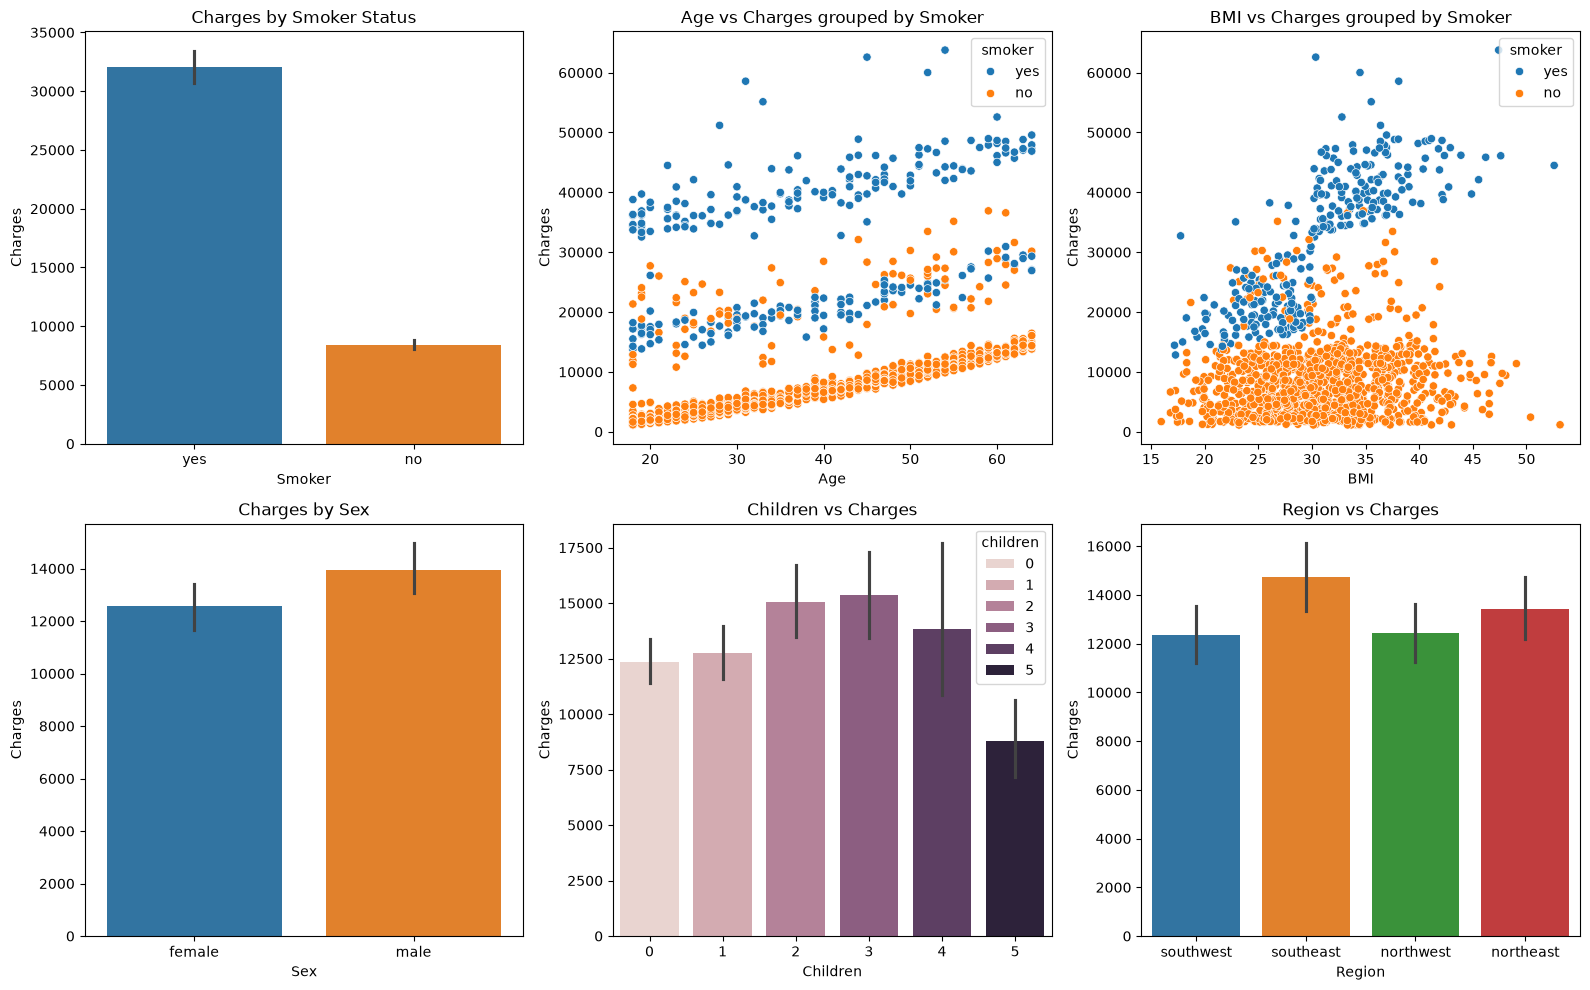

In [105]:
%matplotlib inline

# สร้าง Figure ขนาดรวมที่มี 1 แถว 2 คอลัมน์
fig, ((ax1, ax2,ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(16, 10))

# กราฟที่ 1: Boxplot (บนซ้าย)
sns.barplot(x="smoker", y="charges", hue="smoker", data=df, ax=ax1)
ax1.set_title("Charges by Smoker Status")
ax1.set_xlabel("Smoker")
ax1.set_ylabel("Charges")

# กราฟที่ 2: Scatterplot (บนกลาง)
sns.scatterplot(x="age", y="charges", hue="smoker", data=df, ax=ax2)
ax2.set_title("Age vs Charges grouped by Smoker")
ax2.set_xlabel("Age")
ax2.set_ylabel("Charges")

# กราฟที่ 3: Scatterplot (บนขวา)
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df, ax=ax3)
ax3.set_title("BMI vs Charges grouped by Smoker")
ax3.set_xlabel("BMI")
ax3.set_ylabel("Charges")

# กราฟที่ 4: Boxplot (ล่างซ้าย)
sns.barplot(x="sex", y="charges", hue="sex",data=df, ax=ax4)
ax4.set_title("Charges by Sex")
ax4.set_xlabel("Sex")
ax4.set_ylabel("Charges")

sns.barplot(x="children", y="charges",hue="children", data=df, ax=ax5)
ax5.set_title("Children vs Charges")
ax5.set_xlabel("Children")
ax5.set_ylabel("Charges")

sns.barplot(x="region", y="charges",hue="region", data=df, ax=ax6)
ax6.set_title("Region vs Charges")
ax6.set_xlabel("Region")
ax6.set_ylabel("Charges")

#ขาด region

# ปรับระยะห่างระหว่างกราฟไม่ให้ข้อความทับกัน
plt.tight_layout()
plt.show()

จากสมมุติฐาน
*   age อายุ = ยิ่งอายุมาก ยิ่งแพง
*   *sex เพศ = ไม่น่าส่งผล?
*   bmi	= ยิ่งอ้วน ยิ่งแพง
*   *children จำนวนลูก = ไม่น่าส่งผล?
*   smoker = ถ้าสูบ น่าจะแพงมาก
*   region ภาค = ไม่น่าส่งผล?

จากกราฟจะเห็นว่า age,bmi เป็นไปตามสมมุติฐานที่ตั้งไว้ คือ ยิ่งมากยิ่งแพง



แต่กราฟเหล่านี้ยังมีข้อจำกัด เช่น <br>ในข้อมูลชุดนี้ผู้ชายมีจำนวนคนที่สูบบุหรี่เยอะกว่าผู้หญิง <br>ทำให้ค่าเฉลี่ยเบี้ยประกันออกมาสูงกว่า

In [106]:
# คำนวณจำนวนและ % คนสูบบุหรี่แยกตามเพศ
smoker_df = df[df["smoker"] == "yes"]

counts = smoker_df["sex"].value_counts()
percentages = smoker_df["sex"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"จำนวน (คน)": counts, "สัดส่วน (%)": percentages.round(2)})

print("--- จำนวนและสัดส่วนคนสูบบุหรี่แยกตามเพศ ---")
print(summary)

--- จำนวนและสัดส่วนคนสูบบุหรี่แยกตามเพศ ---
        จำนวน (คน)  สัดส่วน (%)
sex                            
male           159        58.03
female         115        41.97


In [107]:
# คำนวณจำนวนคนสูบบุหรี่และอัตราส่วน % คนสูบบุหรี่ภายในแต่ละเพศ
gender_smoker = (
    pd.crosstab(df["sex"], df["smoker"], normalize="index") * 100
).round(2)
gender_smoker_count = pd.crosstab(df["sex"], df["smoker"])

# รวมเป็นตารางสรุป
summary_gender = pd.DataFrame(
    {
        "จำนวนคนสูบ (คน)": gender_smoker_count["yes"],
        "จำนวนคนไม่สูบ (คน)": gender_smoker_count["no"],
        "สัดส่วนคนสูบภายในเพศ (%)": gender_smoker["yes"],
    }
)

print("--- อัตราส่วนการสูบบุหรี่ คิดจากจำนวนประชากรในแต่ละเพศ ---")
print(summary_gender)

--- อัตราส่วนการสูบบุหรี่ คิดจากจำนวนประชากรในแต่ละเพศ ---
        จำนวนคนสูบ (คน)  จำนวนคนไม่สูบ (คน)  สัดส่วนคนสูบภายในเพศ (%)
sex                                                                  
female              115                 547                     17.37
male                159                 517                     23.52


ถ้าวัดกันหมัดต่อหมัดหลังตัดผลกระทบของบุหรี่และตัวแปรอื่นๆออกไปล่ะ?

##4.Model training

###4.1 เทรนด้วยทุก column ตรงๆ

In [108]:
# 1. โหลดข้อมูล
features = ["age", "sex", "bmi", "children", "smoker", "region"]

# 2. แปลงเป็น One-Hot Encoding
X = pd.get_dummies(df[features], drop_first=True)
y = df["charges"]

# 3. แบ่งข้อมูลเป็น Train และ Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. เทรนโมเดล
model = LinearRegression().fit(X_train, y_train)

# 5. แสดงผลลัพธ์
print("Train R^2 =", model.score(X_train, y_train))
print("Test R^2 =", model.score(X_test, y_test))

print("\n--- Coefficients ---")
print(pd.Series(model.coef_, index=X.columns))

mean_charge = y_test.mean()

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Charge : ${mean_charge:,.2f}")
print(f"MAE (Error) : ${mae:,.2f} ({mae/mean_charge*100:.1f}%)")

Train R^2 = 0.7417255854683333
Test R^2 = 0.7835929767120723

--- Coefficients ---
age                   256.975706
bmi                   337.092552
children              425.278784
sex_male              -18.591692
smoker_yes          23651.128856
region_northwest     -370.677326
region_southeast     -657.864297
region_southwest     -809.799354
dtype: float64
Mean Charge : $12,968.32
MAE (Error) : $4,181.19 (32.2%)


get_dummies

.fit()

mae

mae vs rmse

###4.2เทรนแบบมีชั้นเชิง

จำกราฟนี้ได้ไหม?
<br>จะเห็นว่า bmi จะส่งผลต่อเบี้ยประกันมากกว่า "ถ้าสูบบุหรี่"

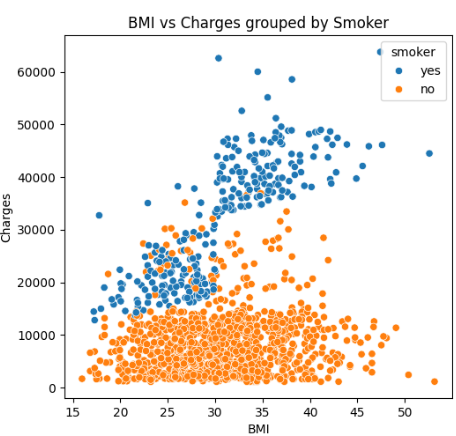

In [109]:
# 2. เพิ่ม Interaction Term ระหว่าง bmi และ smoker
# (เนื่องจากคนสูบบุหรี่ที่มี BMI สูงจะมีค่าเบี้ยประกันพุ่งสูงเป็นพิเศษ)
df['bmi_smoker'] = df['bmi'] * (df['smoker'] == 'yes')

features = ["age", "sex", "bmi", "children", "smoker", "region", "bmi_smoker"]

# 3. แปลงเป็น One-Hot Encoding
X = pd.get_dummies(df[features], drop_first=True)
y = df["charges"]

# 4. แบ่งข้อมูลเป็น Train และ Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. เทรนโมเดล
model = LinearRegression().fit(X_train, y_train)

# 6. แสดงผลลัพธ์
print("Train R^2 =", model.score(X_train, y_train))
print("Test R^2  =", model.score(X_test, y_test))

print("\n--- Coefficients ---")
print(pd.Series(model.coef_, index=X.columns))

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mean_charge = y_test.mean()
print(f"Mean Charge : ${mean_charge:,.2f}")
print(f"MAE (Error) : ${mae:,.2f} ({mae/mean_charge*100:.1f}%)")

Train R^2 = 0.83407050648111
Test R^2  = 0.8652503208873077

--- Coefficients ---
age                   263.390620
bmi                    20.250788
children              463.652623
bmi_smoker           1470.862534
sex_male             -525.230854
smoker_yes         -21206.908812
region_northwest     -631.416402
region_southeast     -967.480455
region_southwest    -1233.426402
dtype: float64
Mean Charge : $12,968.32
MAE (Error) : $2,756.90 (21.3%)


In [110]:
X.head()

,age,bmi,children,bmi_smoker,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,27.9,False,True,False,False,True
1,18,33.770,1,0.0,True,False,False,True,False
2,28,33.000,3,0.0,True,False,False,True,False
3,33,22.705,0,0.0,True,False,True,False,False
4,32,28.880,0,0.0,True,False,True,False,False


*พิเศษ ใช้ model ที่เทรนกันมา สร้างกราฟของผลกระทบจากแต่ละตัวแปร โดยที่คุมไม่ให้ตัวแปรอื่นส่งผล
<br>เพื่อดูว่า parameter ส่งผลอย่างไร

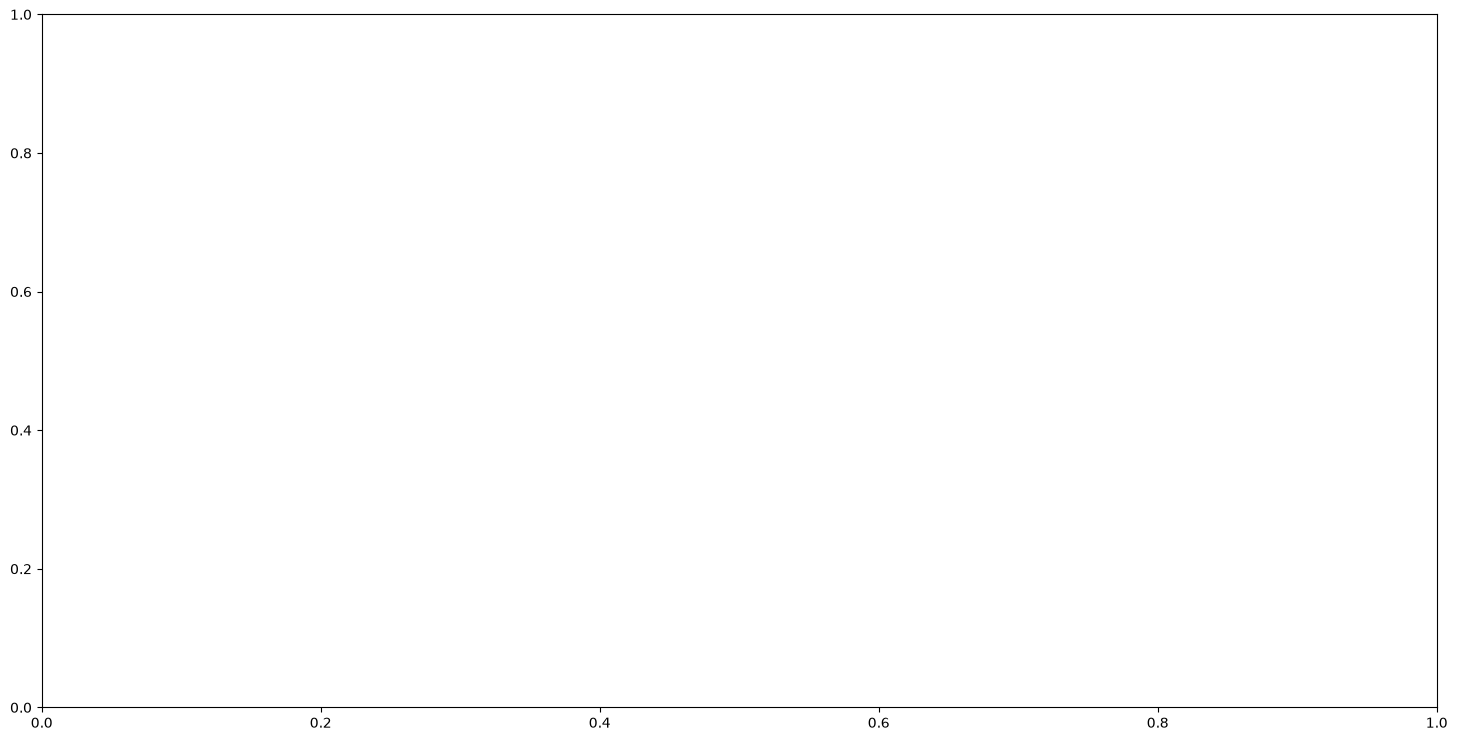

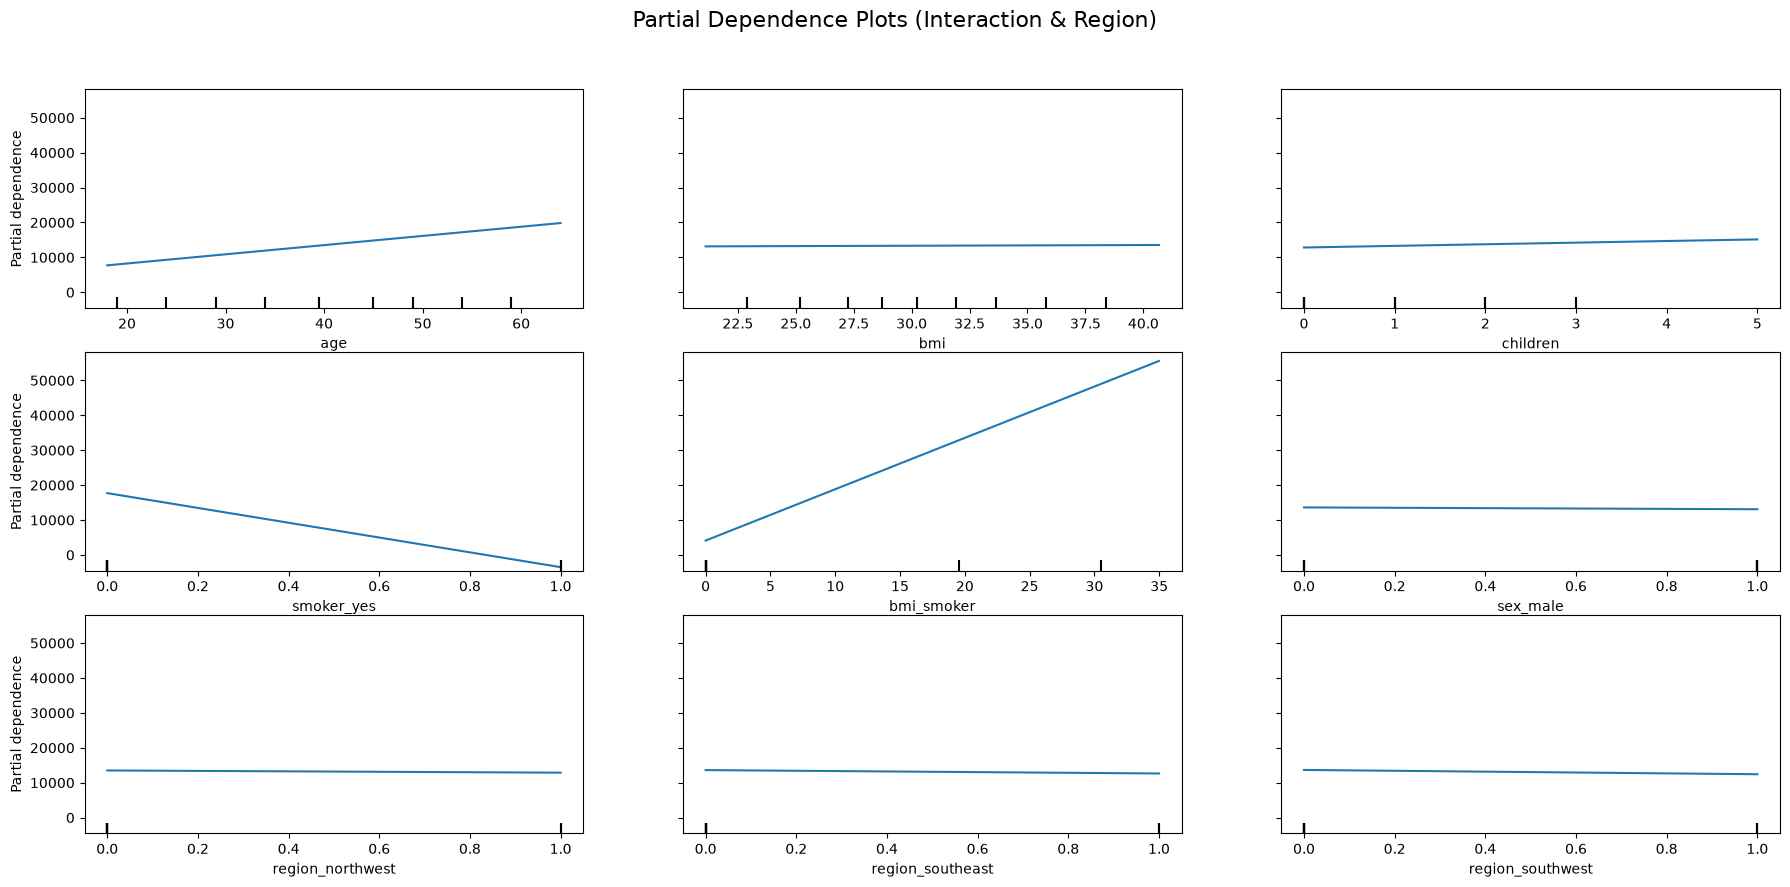

In [111]:
# 1. กำหนด Features ที่ต้องการพล็อตให้ครบทุกตัวแปร (รวม sex และ region ทุกหมวด)
features_to_plot = [
    'age',
    'bmi',
    'children',
    'smoker_yes',
    'bmi_smoker',        # Interaction Term ที่สร้างขึ้นใหม่
    'sex_male',          # เพศ (1 = male, 0 = female)
    'region_northwest',  # ภูมิภาคเทียบกับ northeast
    'region_southeast',
    'region_southwest'
]

# 2. สร้าง Grid สำหรับวางกราฟ (เช่น 2 แถว 4 คอลัมน์)
fig, ax = plt.subplots(figsize=(18, 9))

# แปลงข้อมูล X_train ให้เป็น Float ทั้งหมด
X_train_float = X_train.astype(float)

fig, ax = plt.subplots(figsize=(18, 9))

# 3. วาด PDP ครบทุก Feature
PartialDependenceDisplay.from_estimator(
    model,
    X_train_float, # <--- แก้ไขจุดนี้
    features_to_plot,
    grid_resolution=50,
    ax=ax
)

plt.suptitle("Partial Dependence Plots (Interaction & Region)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

##5.บันทึก model ที่เราเทรนกันมา

In [ ]:
model_package = {
    "model": model,
    "features": features
}

joblib.dump(model_package, "../src/insurance_model.joblib")
print("Saved: insurance_model.joblib")

Saved: health_insurance_lr_mvp.joblib
